# Experimento A

In [2]:
DATASET_TRAIN = Path(
    r"C:\Users\Maria\Desktop\PROYECTO MALARIA\BeerLaNet prove\BeerLaNet\dataset\train"
)

OUTPUT_DIR = Path(
    r"C:\Users\Maria\Desktop\PROYECTO MALARIA\BeerLaNet prove\BeerLaNet\dataset\results"
)

In [3]:
from pathlib import Path

print("Dataset:", DATASET_TRAIN)
print("\nContenido:")

for item in DATASET_TRAIN.iterdir():
    print(item)

Dataset: C:\Users\Maria\Desktop\PROYECTO MALARIA\BeerLaNet prove\BeerLaNet\dataset\train

Contenido:
C:\Users\Maria\Desktop\PROYECTO MALARIA\BeerLaNet prove\BeerLaNet\dataset\train\infectado
C:\Users\Maria\Desktop\PROYECTO MALARIA\BeerLaNet prove\BeerLaNet\dataset\train\sano


In [13]:
extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

images = [
    p for p in DATASET_TRAIN.rglob("*")
    if p.is_file() and p.suffix.lower() in extensions
]

print(f"Imágenes encontradas: {len(images)}")

for p in images[:5]:
    print(p)

Imágenes encontradas: 8203
C:\Users\Maria\Desktop\PROYECTO MALARIA\BeerLaNet prove\BeerLaNet\dataset\train\infectado\000_seg0_cls0.png
C:\Users\Maria\Desktop\PROYECTO MALARIA\BeerLaNet prove\BeerLaNet\dataset\train\infectado\000_seg10_cls0.png
C:\Users\Maria\Desktop\PROYECTO MALARIA\BeerLaNet prove\BeerLaNet\dataset\train\infectado\000_seg11_cls0.png
C:\Users\Maria\Desktop\PROYECTO MALARIA\BeerLaNet prove\BeerLaNet\dataset\train\infectado\000_seg12_cls0.png
C:\Users\Maria\Desktop\PROYECTO MALARIA\BeerLaNet prove\BeerLaNet\dataset\train\infectado\000_seg13_cls0.png


In [6]:
import sys
from pathlib import Path

ROOT_DIR = Path(r"C:\Users\Maria\Desktop\PROYECTO MALARIA\BeerLaNet prove\BeerLaNet")

sys.path.insert(0, str(ROOT_DIR))

from src.BeerLaNet import BeerLaNet


In [7]:
import torch
from PIL import Image
from torchvision import transforms

device = torch.device("cpu")

beerlanet = BeerLaNet(
    r=8,
    c=3,
    learn_S_init=True,
    calc_tau=True
).to(device)

beerlanet.eval()

img_path = images[0]

img = Image.open(img_path).convert("RGB")

transform = transforms.ToTensor()

X = transform(img).unsqueeze(0).to(device)

print("Imagen:", img_path)
print("Tensor:", X.shape)

Imagen: C:\Users\Maria\Desktop\PROYECTO MALARIA\BeerLaNet prove\BeerLaNet\dataset\train\infectado\000_seg0_cls0.png
Tensor: torch.Size([1, 3, 256, 256])


In [8]:
with torch.no_grad():
    x0, S, D = beerlanet(
        X,
        S=None,
        D=None,
        n_iter=10,
        unit_norm_S=True
    )

print("x0:", x0.shape)
print("S:", S.shape)
print("D:", D.shape)

x0: torch.Size([1, 3, 1])
S: torch.Size([3, 8])
D: torch.Size([1, 8, 256, 256])


# Los resultados para una celula infectada usando BeerLaNet :

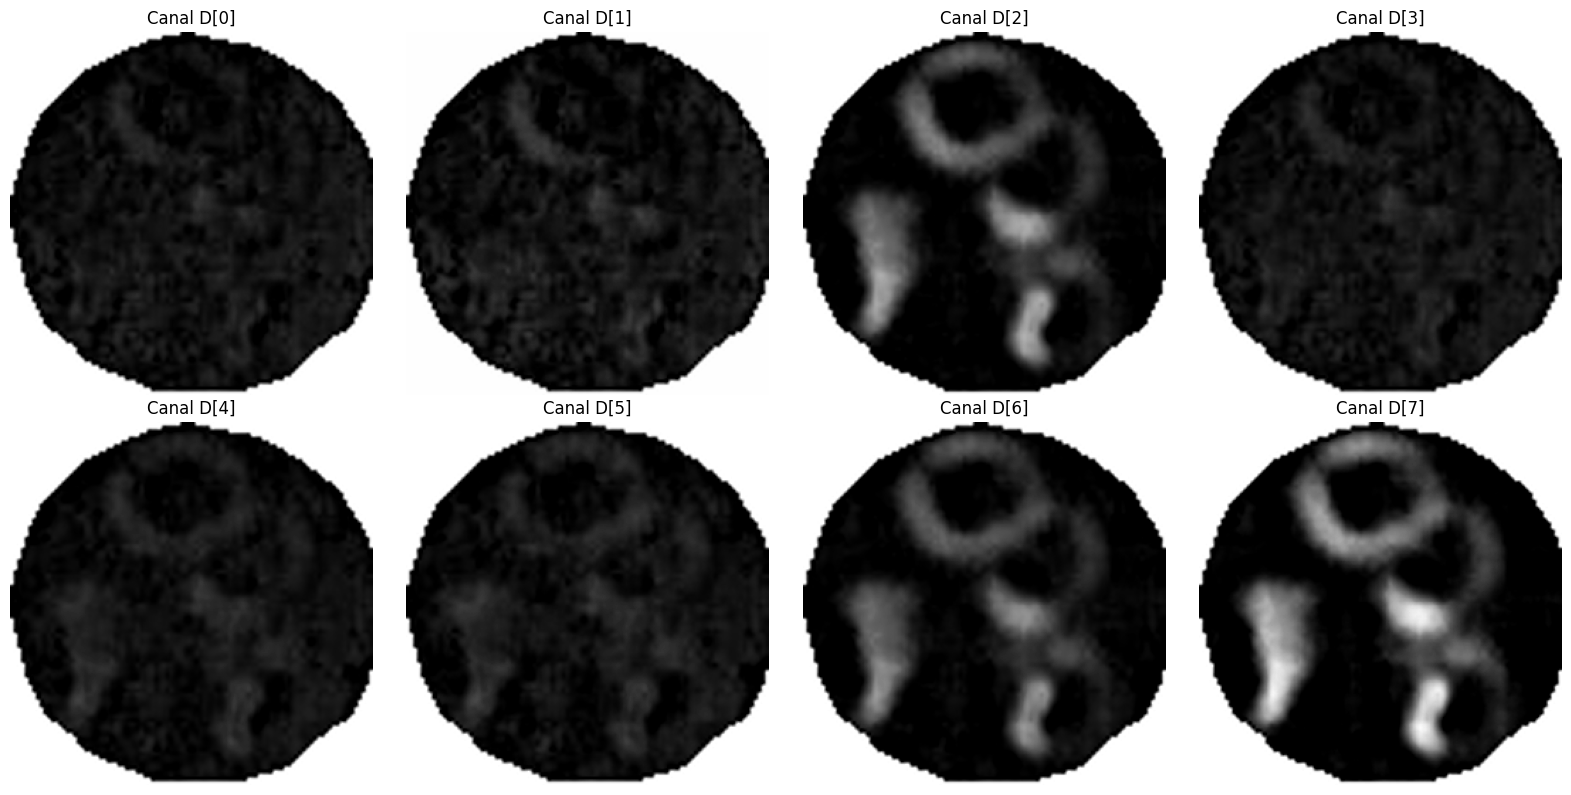

In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, ax in enumerate(axes.flat):
    ax.imshow(D[0, i].cpu().numpy(), cmap="gray")
    ax.set_title(f"Canal D[{i}]")
    ax.axis("off")

plt.tight_layout()

plt.show()

# Para una celula no infectada 

In [21]:
healthy_images = [
    p for p in images
    if "sano" in p.parts
]

print(f"Células sanas encontradas: {len(healthy_images)}")
print(healthy_images[:5])

Células sanas encontradas: 4355
[WindowsPath('C:/Users/Maria/Desktop/PROYECTO MALARIA/BeerLaNet prove/BeerLaNet/dataset/train/sano/000-23_seg0_cls0.png'), WindowsPath('C:/Users/Maria/Desktop/PROYECTO MALARIA/BeerLaNet prove/BeerLaNet/dataset/train/sano/000-23_seg10_cls0.png'), WindowsPath('C:/Users/Maria/Desktop/PROYECTO MALARIA/BeerLaNet prove/BeerLaNet/dataset/train/sano/000-23_seg11_cls0.png'), WindowsPath('C:/Users/Maria/Desktop/PROYECTO MALARIA/BeerLaNet prove/BeerLaNet/dataset/train/sano/000-23_seg12_cls0.png'), WindowsPath('C:/Users/Maria/Desktop/PROYECTO MALARIA/BeerLaNet prove/BeerLaNet/dataset/train/sano/000-23_seg13_cls0.png')]


In [24]:
img_paths = healthy_images[0]

imgs = Image.open(img_paths).convert("RGB")

transform = transforms.ToTensor()

Xs = transform(imgs).unsqueeze(0).to(device)

print("Imagen:", img_paths)
print("Tensor:", Xs.shape)

Imagen: C:\Users\Maria\Desktop\PROYECTO MALARIA\BeerLaNet prove\BeerLaNet\dataset\train\sano\000-23_seg0_cls0.png
Tensor: torch.Size([1, 3, 256, 256])


In [25]:
with torch.no_grad():
    x0, S, D = beerlanet(
        Xs,
        S=None,
        D=None,
        n_iter=10,
        unit_norm_S=True
    )

print("x0:", x0.shape)
print("S:", S.shape)
print("D:", D.shape)

x0: torch.Size([1, 3, 1])
S: torch.Size([3, 8])
D: torch.Size([1, 8, 256, 256])


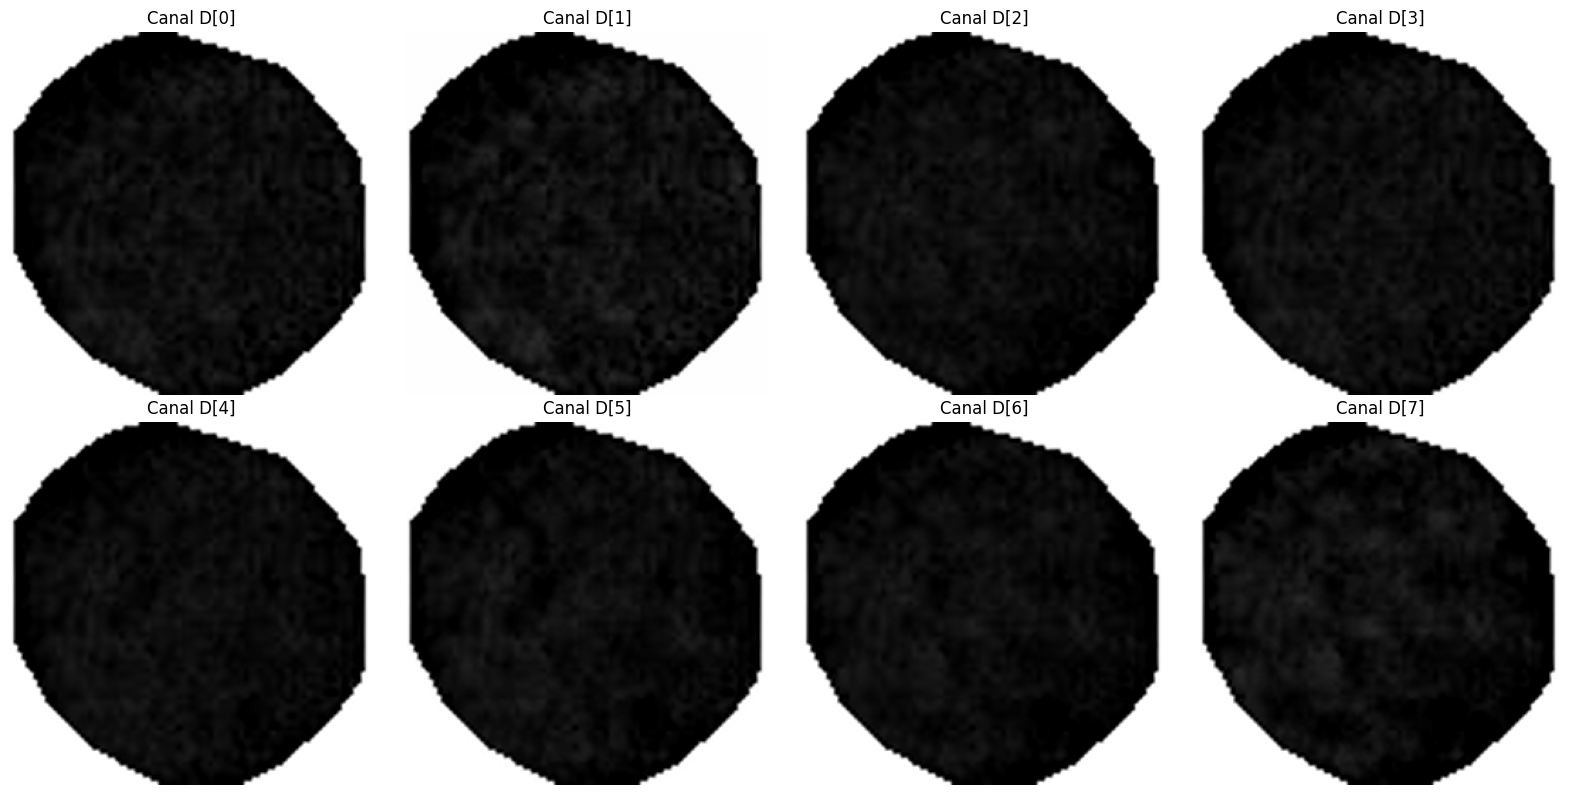

In [26]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, ax in enumerate(axes.flat):
    ax.imshow(D[0, i].cpu().numpy(), cmap="gray")
    ax.set_title(f"Canal D[{i}]")
    ax.axis("off")

plt.tight_layout()

plt.show()

# Revisando que tan bueno resalta la malaria 

In [29]:
healthy_images = [
    p for p in images
    if "sano" in p.parts
]

infected_images = [
    p for p in images
    if "infectado" in p.parts
]
print(f"Healthy:  {len(healthy_images)} imágenes")
print(f"Infected: {len(infected_images)} imágenes")

Healthy:  4355 imágenes
Infected: 3848 imágenes


In [30]:
healthy_path = healthy_images[0]
infected_path = infected_images[0]

print("\nHealthy:")
print(healthy_path)

print("\nInfected:")
print(infected_path)


Healthy:
C:\Users\Maria\Desktop\PROYECTO MALARIA\BeerLaNet prove\BeerLaNet\dataset\train\sano\000-23_seg0_cls0.png

Infected:
C:\Users\Maria\Desktop\PROYECTO MALARIA\BeerLaNet prove\BeerLaNet\dataset\train\infectado\000_seg0_cls0.png


In [31]:
transform = transforms.ToTensor()


def apply_beerlanet(image_path):
    img = Image.open(image_path).convert("RGB")
    X = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        x0, S, D = beerlanet(
            X,
            S=None,
            D=None,
            n_iter=10,
            unit_norm_S=True
        )

    return img, D

In [32]:
healthy_img, D_healthy = apply_beerlanet(healthy_path)
infected_img, D_infected = apply_beerlanet(infected_path)

In [33]:
print("\nResultados BeerLaNet:")
print("Healthy D: ", D_healthy.shape)
print("Infected D:", D_infected.shape)


Resultados BeerLaNet:
Healthy D:  torch.Size([1, 8, 256, 256])
Infected D: torch.Size([1, 8, 256, 256])


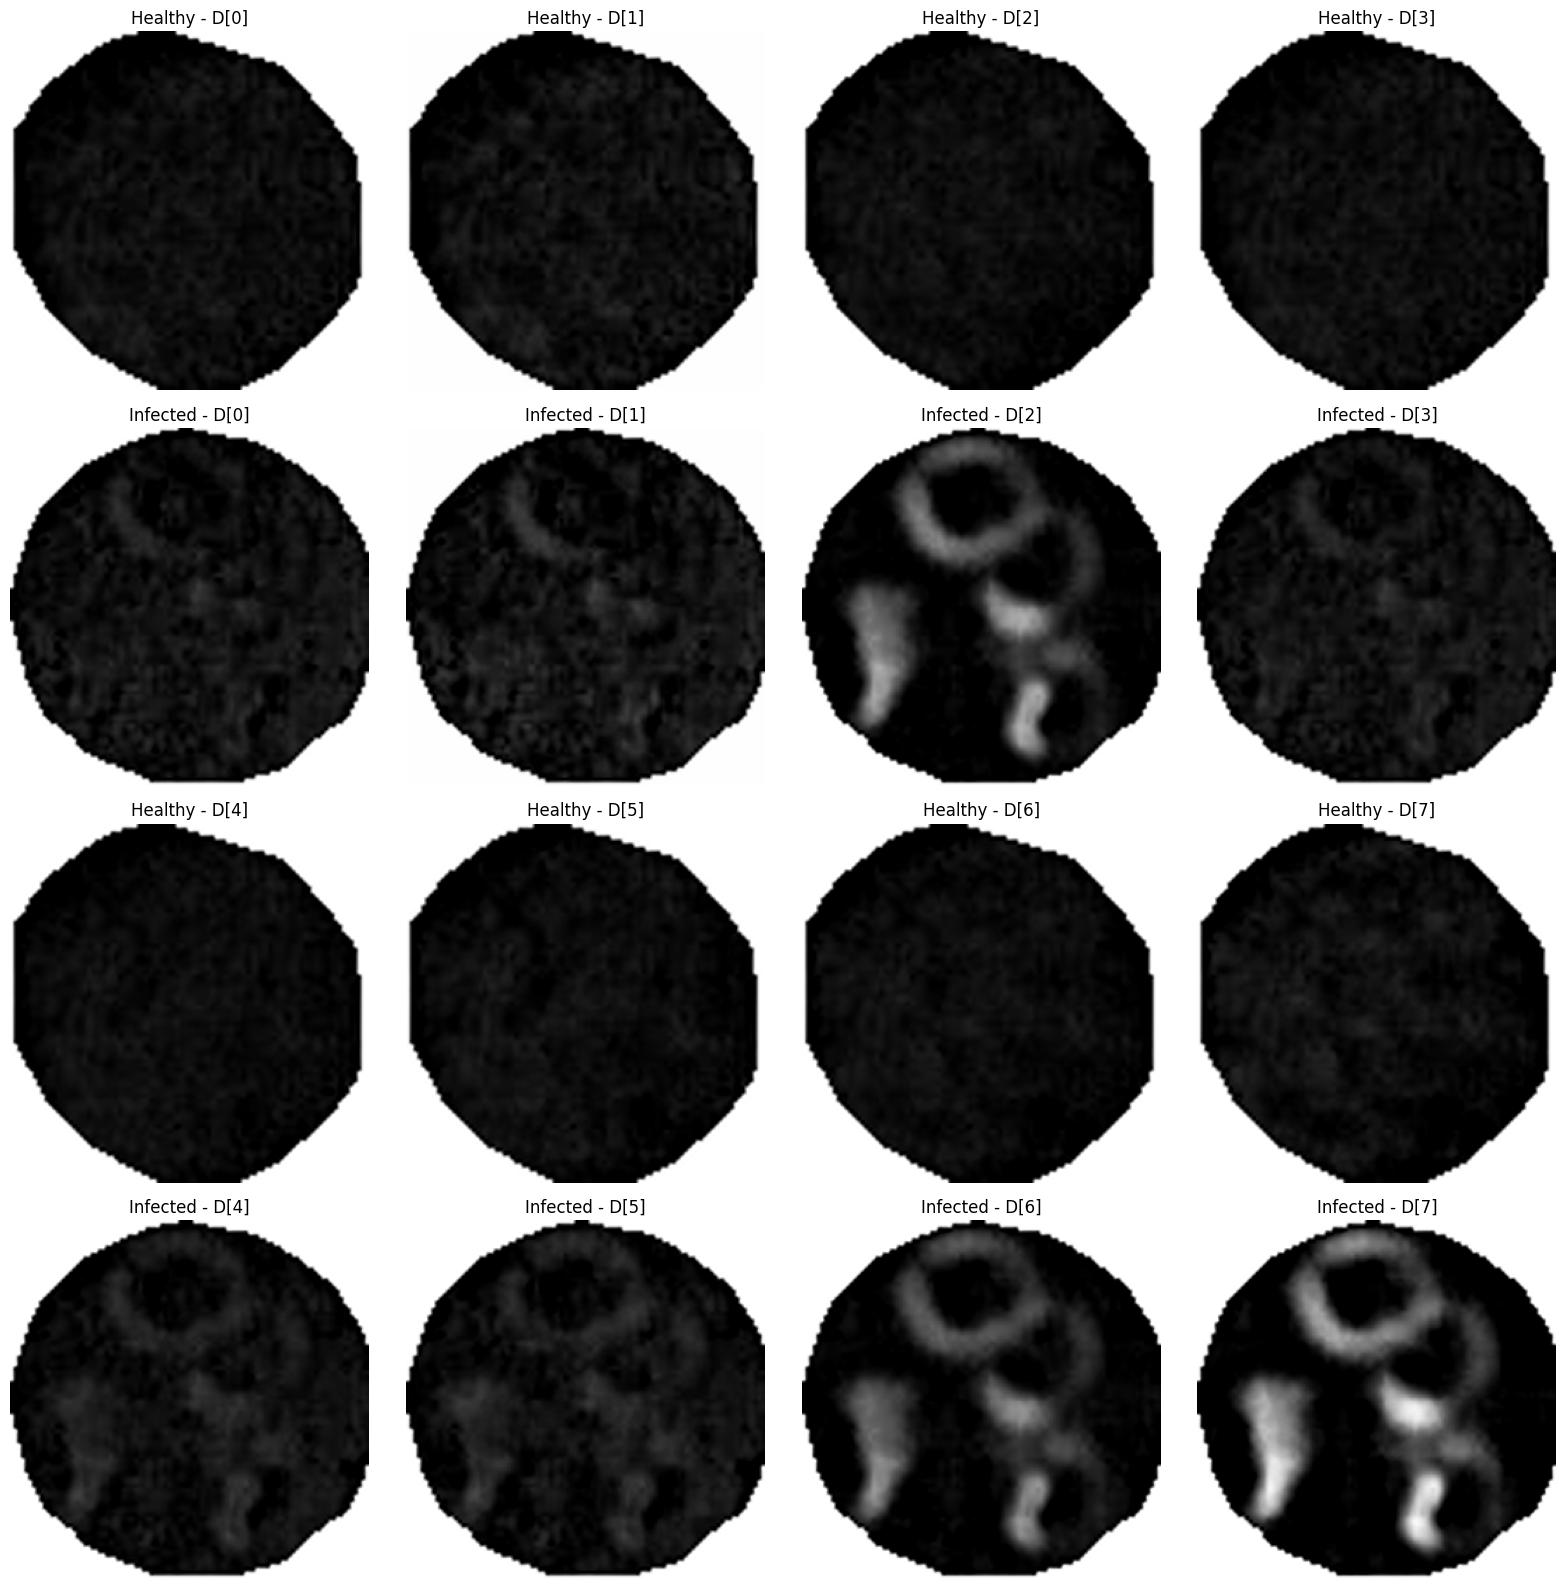

In [34]:
fig, axes = plt.subplots(4, 4, figsize=(16, 16))

for i in range(8):

    # Healthy
    axes[i // 4 * 2, i % 4].imshow(
        D_healthy[0, i].cpu().numpy(),
        cmap="gray"
    )
    axes[i // 4 * 2, i % 4].set_title(f"Healthy - D[{i}]")
    axes[i // 4 * 2, i % 4].axis("off")

    # Infected
    axes[i // 4 * 2 + 1, i % 4].imshow(
        D_infected[0, i].cpu().numpy(),
        cmap="gray"
    )
    axes[i // 4 * 2 + 1, i % 4].set_title(f"Infected - D[{i}]")
    axes[i // 4 * 2 + 1, i % 4].axis("off")

plt.tight_layout()
plt.show()

# Revisando estadisticamente los canales  D 

In [35]:

N = 20

healthy_sample = healthy_images[:N]
infected_sample = infected_images[:N]

print(f"Healthy seleccionadas:  {len(healthy_sample)}")
print(f"Infected seleccionadas: {len(infected_sample)}")

if len(healthy_sample) < N or len(infected_sample) < N:
    raise ValueError("No hay suficientes imágenes para tomar 20 de cada clase.")



Healthy seleccionadas:  20
Infected seleccionadas: 20


In [36]:
transform = transforms.ToTensor()

def extract_D_features(image_path, label):
    
    img = Image.open(image_path).convert("RGB")
    X = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        _, _, D = beerlanet(
            X,
            S=None,
            D=None,
            n_iter=10,
            unit_norm_S=True
        )

    # D: [1, 8, H, W]
    D = D[0].cpu()

    features = {
        "image": image_path.name,
        "path": str(image_path),
        "class": label
    }

    # Estadísticas de cada uno de los 8 canales
    for i in range(8):
        channel = D[i]

        features[f"D{i}_mean"] = channel.mean().item()
        features[f"D{i}_std"] = channel.std().item()
        features[f"D{i}_max"] = channel.max().item()

    return features

In [37]:
results = []

print("\nProcesando healthy...")

for i, path in enumerate(healthy_sample):
    results.append(
        extract_D_features(path, "healthy")
    )
    print(f"  {i+1:02d}/20", end="\r")

print("\nProcesando infected...")

for i, path in enumerate(infected_sample):
    results.append(
        extract_D_features(path, "infected")
    )
    print(f"  {i+1:02d}/20", end="\r")



Procesando healthy...
  20/20
Procesando infected...
  20/20

In [39]:
import pandas as pd
df = pd.DataFrame(results)

print("\n\nDataFrame:")
display(df.head())

print("\nDimensiones:", df.shape)



DataFrame:


,image,path,class,D0_mean,D0_std,D0_max,D1_mean,D1_std,D1_max,D2_mean,...,D4_max,D5_mean,D5_std,D5_max,D6_mean,D6_std,D6_max,D7_mean,D7_std,D7_max
0,000-23_seg0_cls0.png,C:\Users\Maria\Desktop\PROYECTO MALARIA\BeerLa...,healthy,0.051044,0.076610,0.192378,0.046780,0.068954,0.174464,0.057761,...,0.217793,0.053827,0.082440,0.206136,0.058455,0.090225,0.224527,0.050252,0.076011,0.190035
1,000-23_seg10_cls0.png,C:\Users\Maria\Desktop\PROYECTO MALARIA\BeerLa...,healthy,0.076581,0.093438,0.203392,0.070203,0.084311,0.185083,0.086436,...,0.228222,0.079544,0.099246,0.213794,0.086750,0.108517,0.233699,0.073579,0.091072,0.196843
2,000-23_seg11_cls0.png,C:\Users\Maria\Desktop\PROYECTO MALARIA\BeerLa...,healthy,0.072737,0.092826,0.201403,0.066343,0.083929,0.183162,0.082206,...,0.226217,0.076321,0.098447,0.212307,0.082956,0.107684,0.231806,0.070355,0.090587,0.195485
3,000-23_seg12_cls0.png,C:\Users\Maria\Desktop\PROYECTO MALARIA\BeerLa...,healthy,0.079711,0.095062,0.203807,0.072991,0.085963,0.185666,0.090139,...,0.228470,0.082866,0.100642,0.213795,0.090483,0.110460,0.234300,0.076688,0.092966,0.197645
4,000-23_seg13_cls0.png,C:\Users\Maria\Desktop\PROYECTO MALARIA\BeerLa...,healthy,0.057784,0.088580,0.207881,0.053314,0.080675,0.190483,0.065077,...,0.231707,0.059408,0.092959,0.217245,0.064918,0.102231,0.238244,0.055529,0.086734,0.203292



Dimensiones: (40, 27)


In [41]:
mean_features = [
    f"D{i}_mean"
    for i in range(8)
]

print(mean_features)

['D0_mean', 'D1_mean', 'D2_mean', 'D3_mean', 'D4_mean', 'D5_mean', 'D6_mean', 'D7_mean']


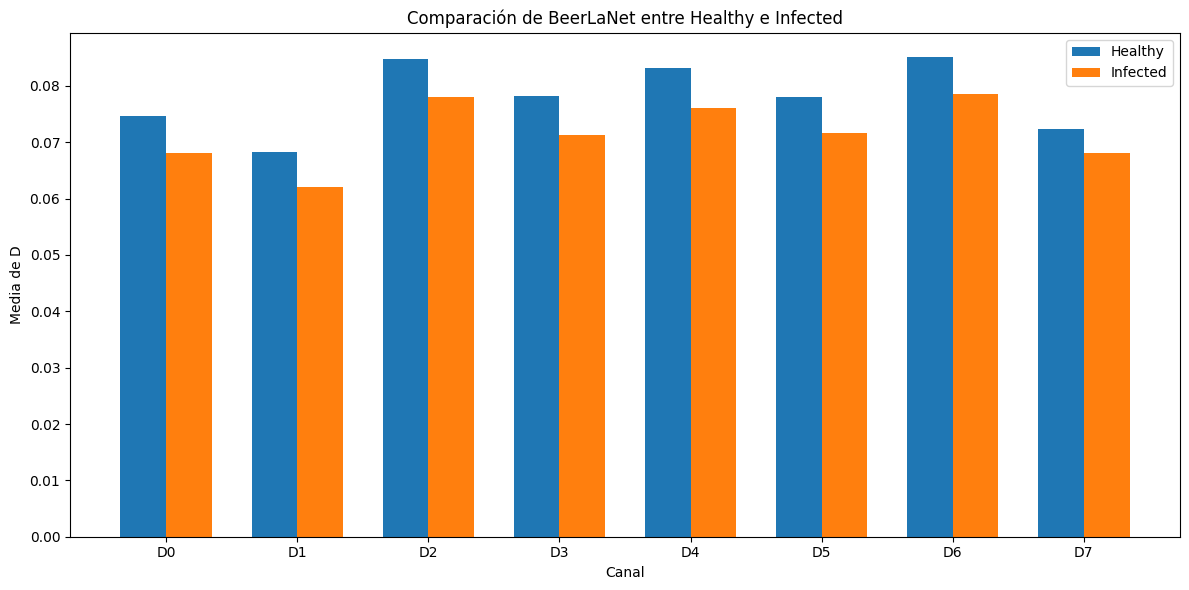

In [43]:
import numpy as np
healthy_means = (
    df[df["class"] == "healthy"][mean_features]
    .mean()
)

infected_means = (
    df[df["class"] == "infected"][mean_features]
    .mean()
)

x = np.arange(8)
width = 0.35

plt.figure(figsize=(12, 6))

plt.bar(
    x - width/2,
    healthy_means.values,
    width,
    label="Healthy"
)

plt.bar(
    x + width/2,
    infected_means.values,
    width,
    label="Infected"
)

plt.xticks(x, [f"D{i}" for i in range(8)])
plt.xlabel("Canal")
plt.ylabel("Media de D")
plt.title("Comparación de BeerLaNet entre Healthy e Infected")
plt.legend()
plt.tight_layout()
plt.show()

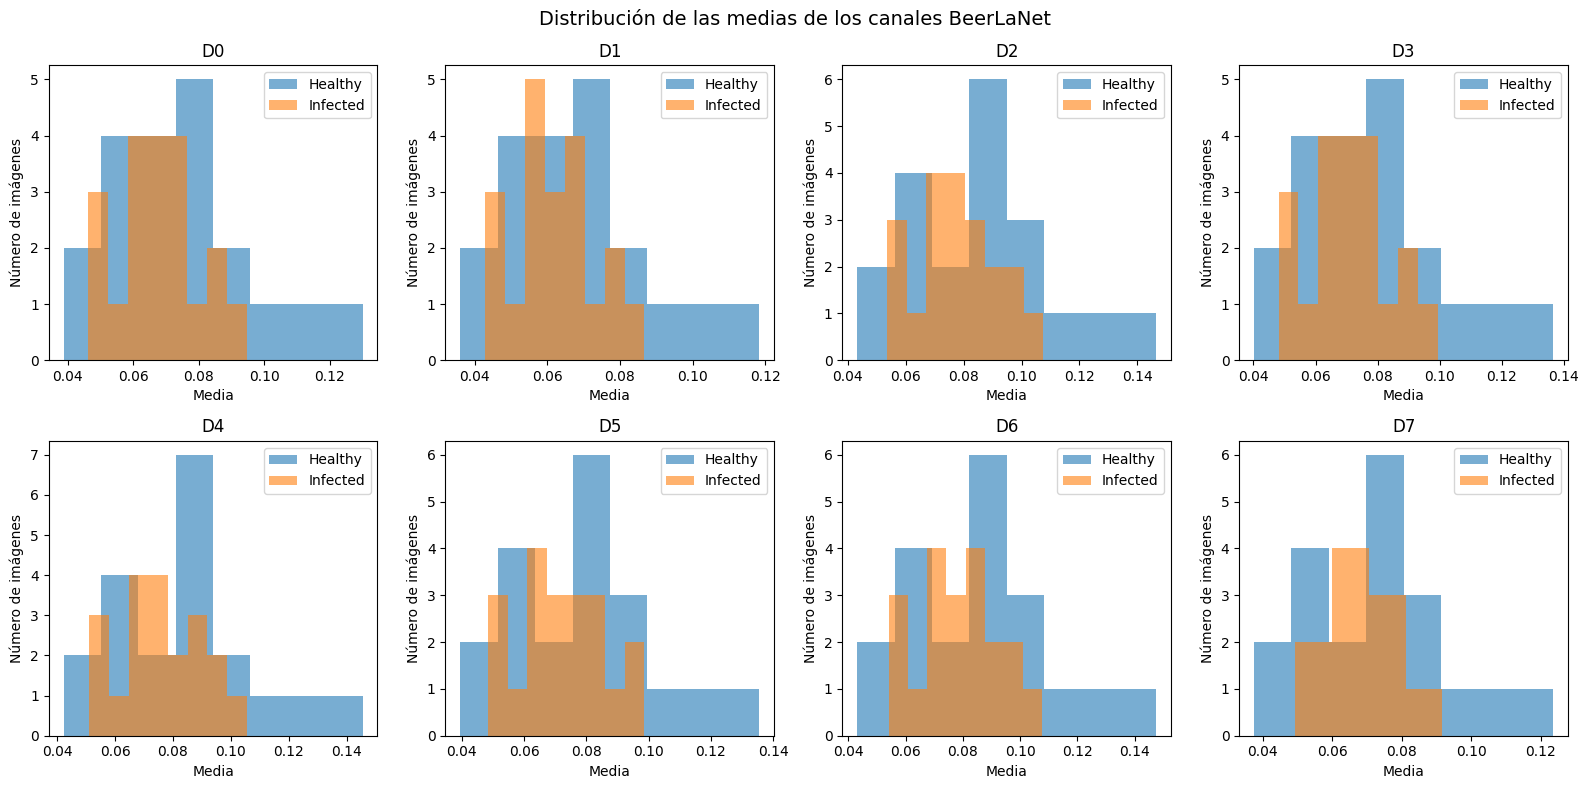

In [44]:
# ============================================================
# Distribución de las medias de cada canal
# ============================================================

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, ax in enumerate(axes.flat):

    healthy_values = df[
        df["class"] == "healthy"
    ][f"D{i}_mean"]

    infected_values = df[
        df["class"] == "infected"
    ][f"D{i}_mean"]

    ax.hist(
        healthy_values,
        bins=8,
        alpha=0.6,
        label="Healthy"
    )

    ax.hist(
        infected_values,
        bins=8,
        alpha=0.6,
        label="Infected"
    )

    ax.set_title(f"D{i}")
    ax.set_xlabel("Media")
    ax.set_ylabel("Número de imágenes")
    ax.legend()

plt.suptitle(
    "Distribución de las medias de los canales BeerLaNet",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [46]:
comparison["difference"] = (
    comparison["healthy"] - comparison["infected"]
)

comparison["relative_difference_%"] = (
    comparison["difference"]
    / comparison["infected"].abs()
) * 100

display(comparison)

class,healthy,infected,difference,relative_difference_%
D0_mean,0.074659,0.068021,0.006638,9.759157
D1_mean,0.068298,0.062127,0.006171,9.932824
D2_mean,0.084696,0.078001,0.006695,8.583368
D3_mean,0.078190,0.071269,0.006922,9.711860
D4_mean,0.083215,0.076090,0.007124,9.362821
D5_mean,0.077946,0.071695,0.006251,8.718410
D6_mean,0.085158,0.078589,0.006568,8.357560
D7_mean,0.072341,0.068089,0.004252,6.245054


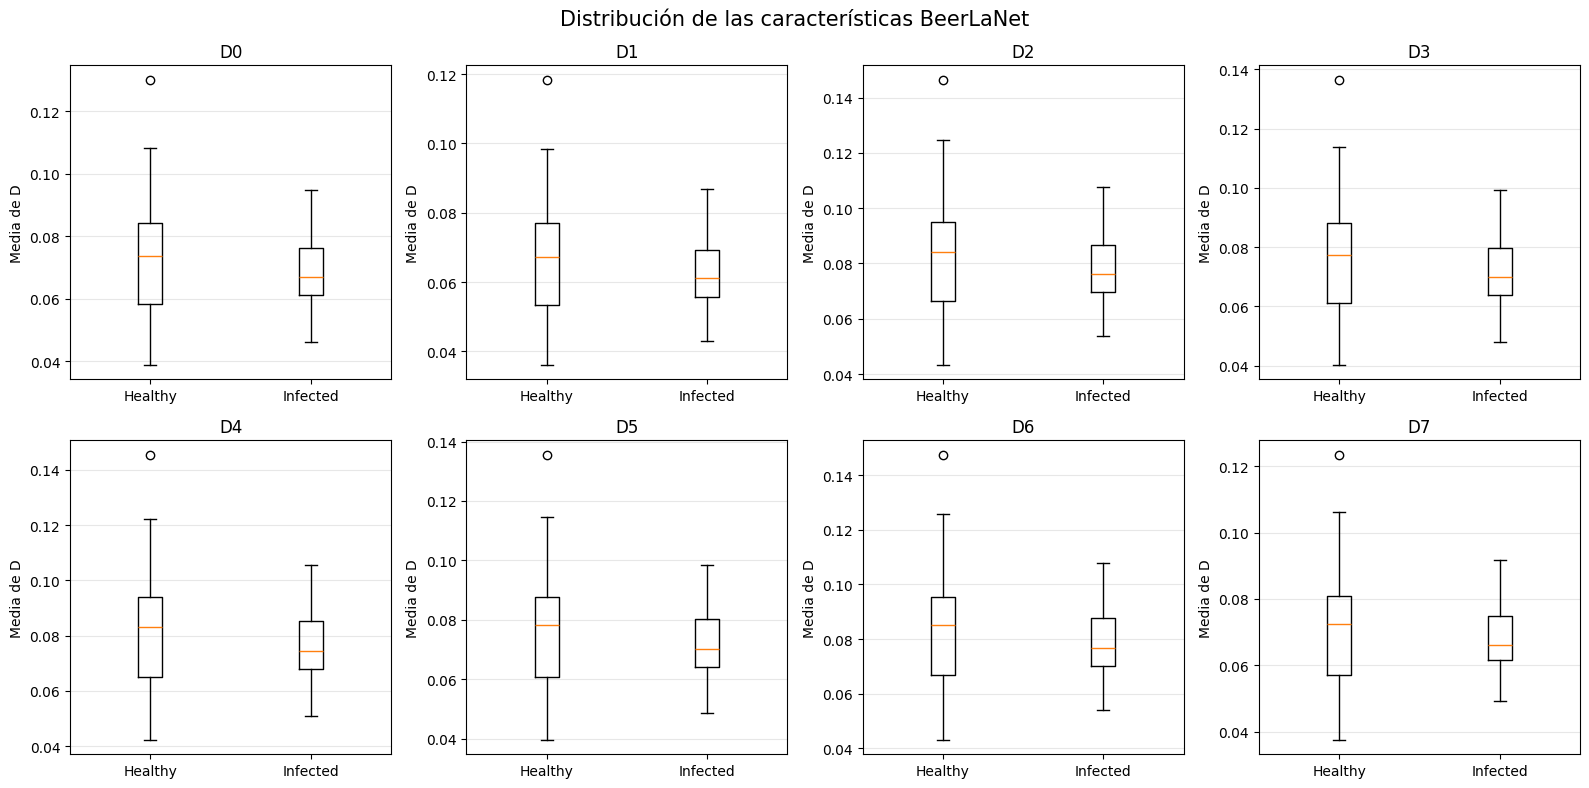

In [47]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, ax in enumerate(axes.flat):

    healthy = df[df["class"] == "healthy"][f"D{i}_mean"]
    infected = df[df["class"] == "infected"][f"D{i}_mean"]

    ax.boxplot(
        [healthy, infected],
        labels=["Healthy", "Infected"]
    )

    ax.set_title(f"D{i}")
    ax.set_ylabel("Media de D")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle(
    "Distribución de las características BeerLaNet",
    fontsize=15
)

plt.tight_layout()
plt.show()

# Probando con Cielab

In [59]:
def path_to_cielab(img_path):
    # Cargar imagen y convertir a RGB
    img = Image.open(img_path).convert("RGB")

    # PIL → NumPy
    img = np.array(img)

    # RGB → CIELAB
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB).astype(np.float32)

    # Convertir a rangos convencionales CIELAB
    lab[:, :, 0] = lab[:, :, 0] * 100 / 255
    lab[:, :, 1] = lab[:, :, 1] - 128
    lab[:, :, 2] = lab[:, :, 2] - 128

    return lab



In [60]:
# Healthy
healthy_images_lab = [
    path_to_cielab(path)
    for path in healthy_images
]

# Infected
infected_images_lab = [
    path_to_cielab(path)
    for path in infected_images
]


In [61]:
print("Healthy:", len(healthy_images_lab))
print("Infected:", len(infected_images_lab))

print("\nPrimera imagen:")
print("Shape:", healthy_images_lab[0].shape)
print("dtype:", healthy_images_lab[0].dtype)

Healthy: 4355
Infected: 3848

Primera imagen:
Shape: (256, 256, 3)
dtype: float32


In [62]:
lab = healthy_images_lab[0]

print("L*:", lab[:, :, 0].min(), "→", lab[:, :, 0].max())
print("a*:", lab[:, :, 1].min(), "→", lab[:, :, 1].max())
print("b*:", lab[:, :, 2].min(), "→", lab[:, :, 2].max())

L*: 0.0 → 100.0
a*: -2.0 → 20.0
b*: -8.0 → 10.0


In [63]:
def apply_beerlanet_lab(image_path):
    # Cargar imagen RGB
    img = Image.open(image_path).convert("RGB")

    # PIL → NumPy
    img_np = np.array(img)

    # RGB → CIELAB
    lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB).astype(np.float32)

    # Ajustar a rangos convencionales CIELAB
    lab[:, :, 0] = lab[:, :, 0] * 100 / 255
    lab[:, :, 1] = lab[:, :, 1] - 128
    lab[:, :, 2] = lab[:, :, 2] - 128

    # CIELAB → Tensor
    X = torch.from_numpy(lab).permute(2, 0, 1).float().unsqueeze(0).to(device)

    with torch.no_grad():
        x0, S, D = beerlanet(
            X,
            S=None,
            D=None,
            n_iter=10,
            unit_norm_S=True
        )

    return lab, D

# Working ...